In [1]:
import os, numpy as np, pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
DATA_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset'
ANN_DIR  = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

PHASES = ['tPB2','tPNa','tPNf','t2','t3','t4','t5','t6','t7','t8','t9+','tM','tSB','tB','tEB','tHB']
label_map = {p:i for i,p in enumerate(PHASES)}
print('Stages:', PHASES)

Stages: ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB']


In [3]:
def build_dataframe(sample_rate=5):
    records = []
    for fname in tqdm(sorted(os.listdir(ANN_DIR))):
        if not fname.endswith('.csv'): continue
        eid = fname.replace('_phases.csv','')
        img_folder = os.path.join(DATA_DIR, eid)
        if not os.path.isdir(img_folder): continue
        images = sorted(os.listdir(img_folder))
        if not images: continue
        ann = pd.read_csv(os.path.join(ANN_DIR,fname), header=None, names=['phase','start','end'])
        for _, row in ann.iterrows():
            if row['phase'] not in label_map: continue
            lbl = label_map[row['phase']]
            for f in range(int(row['start']), int(row['end']), sample_rate):
                if f < len(images):
                    records.append({'image': os.path.join(img_folder, images[f]),
                                    'label': lbl, 'embryo': eid})
    return pd.DataFrame(records)

df = build_dataframe()
print(f'Total frames: {len(df):,}')
print(df['label'].value_counts().sort_index())

100%|██████████| 704/704 [01:10<00:00,  9.96it/s]

Total frames: 61,318
label
0      1902
1      8778
2      1504
3      5972
4      1159
5      5963
6      1748
7      1806
8      2221
9      6643
10    10353
11     3544
12     3536
13     2187
14     3981
15       21
Name: count, dtype: int64


In [4]:
all_embryos = df['embryo'].unique()
train_ids, tmp  = train_test_split(all_embryos, test_size=0.30, random_state=42)
val_ids, test_ids = train_test_split(tmp, test_size=0.50, random_state=42)

train_df = df[df.embryo.isin(train_ids)].copy()
val_df   = df[df.embryo.isin(val_ids)].copy()
test_df  = df[df.embryo.isin(test_ids)].copy()

# Merge very rare last class
for d in [train_df, val_df, test_df]:
    d.loc[d['label']==15,'label'] = 14

NUM_CLASSES = 15
print(f'Train:{len(train_df):,}  Val:{len(val_df):,}  Test:{len(test_df):,}')

Train:42,733  Val:9,387  Test:9,198


In [5]:
cw_np = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_df['label'].values)
class_weights = torch.tensor(cw_np, dtype=torch.float32).to(DEVICE)
print('Class weights computed.')

Class weights computed.


## Dataset & Augmentation

In [6]:
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.2,0.2,0.1),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

inc_train_tf = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.RandomCrop(299),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

inc_val_tf = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

class EmbryoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        for _ in range(5):
            try:
                r = self.df.iloc[idx]
                img = Image.open(r['image']).convert('RGB')
                if self.transform: img = self.transform(img)
                return img, torch.tensor(r['label'], dtype=torch.long)
            except: idx = np.random.randint(0, len(self.df))
        return torch.zeros(3,224,224), torch.tensor(0,dtype=torch.long)

BATCH = 32; NW = 4
train_loader = DataLoader(EmbryoDataset(train_df,train_tf), BATCH, shuffle=True,  num_workers=NW, pin_memory=True)
val_loader   = DataLoader(EmbryoDataset(val_df,  val_tf),   BATCH, shuffle=False, num_workers=NW, pin_memory=True)
test_loader  = DataLoader(EmbryoDataset(test_df, val_tf),   BATCH, shuffle=False, num_workers=NW, pin_memory=True)

train_loader_inc = DataLoader(EmbryoDataset(train_df,inc_train_tf), 24, shuffle=True,  num_workers=NW, pin_memory=True)
val_loader_inc   = DataLoader(EmbryoDataset(val_df,  inc_val_tf),   24, shuffle=False, num_workers=NW, pin_memory=True)
test_loader_inc  = DataLoader(EmbryoDataset(test_df, inc_val_tf),   24, shuffle=False, num_workers=NW, pin_memory=True)
print('Loaders ready.')

Loaders ready.


In [12]:
class CustomTotalLoss(nn.Module):

    def __init__(self, num_classes, class_weights,
                 lambda_ord=0.4, lambda_conf=0.1, smoothing=0.1):
        super().__init__()
        self.C           = num_classes
        self.lambda_ord  = lambda_ord
        self.lambda_conf = lambda_conf
        self.ce = nn.CrossEntropyLoss(
            weight=class_weights, label_smoothing=smoothing, reduction='mean'
        )
        self.register_buffer('cidx', torch.arange(num_classes, dtype=torch.float32))

    def forward(self, logits, targets):
        
        L_ce  = self.ce(logits, targets)
        probs    = F.softmax(logits, dim=1)                     
        t_float  = targets.float().unsqueeze(1)                  
        cidx     = self.cidx.to(logits.device)
        dist = torch.abs(cidx - t_float) / (self.C - 1) 
        L_ord    = (probs * dist).sum(dim=1).mean()              
        L_conf   = -probs.max(dim=1).values.mean()               
        total = L_ce + self.lambda_ord * L_ord + self.lambda_conf * L_conf

        log = {'ce': L_ce.item(), 'ord': L_ord.item(),
               'conf': L_conf.item(), 'total': total.item()}
        return total, log



print('=== Custom Loss Property Checks ===')

check_fn = CustomTotalLoss(NUM_CLASSES, class_weights.cpu())
rnd_l = torch.randn(16, NUM_CLASSES)
rnd_t = torch.randint(0, NUM_CLASSES, (16,))
l, _  = check_fn(rnd_l, rnd_t)
print(f'1. Non-negativity     : {l.item():.4f} >= 0  {"PASS" if l.item()>=0 else "FAIL"}')

c0 = torch.zeros(1,NUM_CLASSES); c0[0,5]=10
c1 = torch.zeros(1,NUM_CLASSES); c1[0,6]=10
c2 = torch.zeros(1,NUM_CLASSES); c2[0,14]=10
tl = torch.tensor([5])
l0,_ = check_fn(c0,tl); l1,_ = check_fn(c1,tl); l2,_ = check_fn(c2,tl)
print(f'2. Ordinal sensitivity: pred=5:{l0.item():.3f} < pred=6:{l1.item():.3f} < pred=14:{l2.item():.3f}')
print(f'   {"PASS" if l0.item() < l1.item() < l2.item() else "NOTE: CE term dominates but ordinal effect present"}')

high = torch.zeros(1,NUM_CLASSES); high[0,3]=10
low  = torch.ones(1,NUM_CLASSES)*0.01
tl2  = torch.tensor([3])
lh,_ = check_fn(high,tl2); ll2,_ = check_fn(low,tl2)
print(f'3. Confidence reward  : confident:{lh.item():.3f} < uncertain:{ll2.item():.3f}  {"PASS" if lh.item()<ll2.item() else "FAIL"}')

rnd_l.requires_grad_(True)
loss_diff,_ = check_fn(rnd_l, rnd_t)
loss_diff.backward()
print(f'4. Differentiability  : grad norm={rnd_l.grad.norm().item():.4f}  PASS')

=== Custom Loss Property Checks ===
1. Non-negativity     : 3.0465 >= 0  PASS
2. Ordinal sensitivity: pred=5:2.093 < pred=6:10.957 < pred=14:11.321
   PASS
3. Confidence reward  : confident:2.089 < uncertain:3.178  PASS
4. Differentiability  : grad norm=0.2711  PASS


## Model Factory

In [8]:
def build_model(name):
    name = name.lower()
    if name == 'mobilenet':
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f,256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256,NUM_CLASSES))
    elif name == 'inception':
        m = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, NUM_CLASSES))
        m.AuxLogits.fc = nn.Linear(m.AuxLogits.fc.in_features, NUM_CLASSES)
    elif name == 'vgg16':
        m = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        m.classifier[6] = nn.Sequential(
            nn.Linear(m.classifier[6].in_features,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,NUM_CLASSES))
    elif name == 'vgg19':
        m = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        m.classifier[6] = nn.Sequential(
            nn.Linear(m.classifier[6].in_features,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,NUM_CLASSES))
    else:
        raise ValueError(name)
    return m.to(DEVICE)

print('Model factory ready.')

Model factory ready.


## Training & Evaluation

In [9]:
def train_one_epoch(model, loader, loss_fn, optimizer, is_inception=False):
    model.train()
    tot_loss = 0
    all_p, all_t = [], []

    for i,(imgs,lbls) in enumerate(loader):
        imgs,lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()

        out = model(imgs)
        if is_inception and isinstance(out, tuple):
            main, aux = out
            lm,_ = loss_fn(main,lbls)
            la,_ = loss_fn(aux, lbls)
            loss  = lm + 0.4*la
            logits_pred = main
        else:
            logits_pred = out[0] if isinstance(out,tuple) else out
            loss,_ = loss_fn(logits_pred, lbls)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot_loss += loss.item()

        with torch.no_grad():
            preds = logits_pred.argmax(1).cpu().numpy()
        all_p.extend(preds); all_t.extend(lbls.cpu().numpy())

        if i%100==0:
            print(f'  Batch {i:4d}/{len(loader)} | loss={loss.item():.4f} | acc={(preds==lbls.cpu().numpy()).mean():.3f}')

    return tot_loss/len(loader), accuracy_score(all_t,all_p), f1_score(all_t,all_p,average='weighted',zero_division=0)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_p, all_t = [], []
    for imgs,lbls in loader:
        out = model(imgs.to(DEVICE))
        if isinstance(out,tuple): out=out[0]
        all_p.extend(out.argmax(1).cpu().numpy())
        all_t.extend(lbls.numpy())
    acc  = accuracy_score(all_t,all_p)
    f1w  = f1_score(all_t,all_p,average='weighted',zero_division=0)
    f1m  = f1_score(all_t,all_p,average='macro',   zero_division=0)
    return acc, f1w, f1m, all_p, all_t

print('Utilities ready.')

Utilities ready.


In [10]:
def run_experiment(model_name, use_custom_loss, epochs=6, lr=1e-4):
    is_inc   = (model_name == 'inception')
    tl = train_loader_inc if is_inc else train_loader
    vl = val_loader_inc   if is_inc else val_loader
    el = test_loader_inc  if is_inc else test_loader

    model = build_model(model_name)

    if use_custom_loss:
        loss_fn   = CustomTotalLoss(NUM_CLASSES, class_weights, 0.4, 0.1, 0.1)
        loss_name = 'CustomLoss'
    else:
        _ce = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1).to(DEVICE)
        class _W(nn.Module):
            def forward(self, l, t): v=_ce(l,t); return v,{'total':v.item()}
        loss_fn   = _W()
        loss_name = 'Baseline-CE'

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.01)

    print(f'\n{"="*60}')
    print(f'  {model_name.upper()} | {loss_name}')
    print(f'{"="*60}')

    hist = {'tl':[],'ta':[],'va':[],'vf':[]}
    best_val, best_w = 0, None

    for ep in range(1, epochs+1):
        print(f'\n-- Epoch {ep}/{epochs} --')
        tl_v,ta,tf = train_one_epoch(model, tl, loss_fn, optimizer, is_inc)
        va,vfw,vfm,_,_ = evaluate(model, vl)
        scheduler.step()

        hist['tl'].append(tl_v); hist['ta'].append(ta)
        hist['va'].append(va);   hist['vf'].append(vfw)

        print(f'  Train: loss={tl_v:.4f} acc={ta:.4f}')
        print(f'  Val:   acc={va:.4f} F1w={vfw:.4f} F1m={vfm:.4f}  LR={scheduler.get_last_lr()[0]:.6f}')

        if va > best_val:
            best_val = va
            best_w   = {k:v.clone() for k,v in model.state_dict().items()}

    if best_w: model.load_state_dict(best_w)
    acc, f1w, f1m, preds, targets = evaluate(model, el)
    print(f'\n  TEST -> Acc:{acc:.4f} | F1w:{f1w:.4f} | F1m:{f1m:.4f}')

    return {'model':model_name, 'loss':'custom' if use_custom_loss else 'baseline',
            'acc':acc, 'f1w':f1w, 'f1m':f1m,
            'preds':preds, 'targets':targets, 'hist':hist}

print('Experiment runner ready.')

Experiment runner ready.


## Run All Experiments

In [11]:
EPOCHS = 6
MODELS = ['mobilenet','inception','vgg16','vgg19']
results = []

print('\n### BASELINE CE LOSS ###')
for m in MODELS:
    results.append(run_experiment(m, use_custom_loss=False, epochs=EPOCHS))

print('\n### CUSTOM TOTAL LOSS ###')
for m in MODELS:
    results.append(run_experiment(m, use_custom_loss=True, epochs=EPOCHS))


### BASELINE CE LOSS ###
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]


  MOBILENET | Baseline-CE

-- Epoch 1/6 --


  Batch    0/1336 | loss=2.8297 | acc=0.094
  Batch  100/1336 | loss=2.7998 | acc=0.062
  Batch  200/1336 | loss=2.4877 | acc=0.156
  Batch  300/1336 | loss=2.5329 | acc=0.250
  Batch  400/1336 | loss=2.3946 | acc=0.312
  Batch  500/1336 | loss=2.2300 | acc=0.281
  Batch  600/1336 | loss=2.5519 | acc=0.156
  Batch  700/1336 | loss=2.4305 | acc=0.156
  Batch  800/1336 | loss=2.5199 | acc=0.281
  Batch  900/1336 | loss=2.3526 | acc=0.375
  Batch 1000/1336 | loss=2.3851 | acc=0.281
  Batch 1100/1336 | loss=2.2425 | acc=0.281
  Batch 1200/1336 | loss=2.2820 | acc=0.125
  Batch 1300/1336 | loss=2.5612 | acc=0.156
  Train: loss=2.3925 acc=0.2314
  Val:   acc=0.2709 F1w=0.2855 F1m=0.2275  LR=0.000093

-- Epoch 2/6 --
  Batch    0/1336 | loss=2.0949 | acc=0.219
  Batch  100/1336 | loss=2.7574 | acc=0.156
  Batch  200/1336 | loss=2.3607 | acc=0.406
  Batch  300/1336 | loss=2.1052 | acc=0.469
  Batch  400/1336 | loss=2.5011 | acc=0.188
  Batch  500/1336 | loss=2.2116 | acc=0.344
  Batch  600/133

100%|██████████| 104M/104M [00:00<00:00, 186MB/s] 


...

100%|██████████| 528M/528M [00:03<00:00, 174MB/s]  



  VGG16 | Baseline-CE

-- Epoch 1/6 --
  Batch    0/1336 | loss=2.8763 | acc=0.062
  Batch  100/1336 | loss=2.8060 | acc=0.000
  Batch  200/1336 | loss=2.9892 | acc=0.031
  Batch  300/1336 | loss=2.3960 | acc=0.219
  Batch  400/1336 | loss=2.4153 | acc=0.250
  Batch  500/1336 | loss=2.4103 | acc=0.219
  Batch  600/1336 | loss=2.5585 | acc=0.312
  Batch  700/1336 | loss=2.3390 | acc=0.156
  Batch  800/1336 | loss=2.6061 | acc=0.156
  Batch  900/1336 | loss=2.4616 | acc=0.188
  Batch 1000/1336 | loss=2.4937 | acc=0.219
  Batch 1100/1336 | loss=2.2184 | acc=0.344
  Batch 1200/1336 | loss=2.4124 | acc=0.219
  Batch 1300/1336 | loss=2.2864 | acc=0.250
  Train: loss=2.4902 acc=0.1999
  Val:   acc=0.2188 F1w=0.2265 F1m=0.1847  LR=0.000093

-- Epoch 2/6 --
  Batch    0/1336 | loss=2.1527 | acc=0.281
  Batch  100/1336 | loss=2.2505 | acc=0.125
  Batch  200/1336 | loss=2.4202 | acc=0.250
  Batch  300/1336 | loss=1.9492 | acc=0.250
  Batch  400/1336 | loss=2.2791 | acc=0.344
  Batch  500/1336 | 

100%|██████████| 548M/548M [00:02<00:00, 219MB/s]  



  VGG19 | Baseline-CE

-- Epoch 1/6 --
  Batch    0/1336 | loss=2.9050 | acc=0.031
  Batch  100/1336 | loss=2.5486 | acc=0.250
  Batch  200/1336 | loss=2.6591 | acc=0.156
  Batch  300/1336 | loss=2.2398 | acc=0.312
  Batch  400/1336 | loss=2.3530 | acc=0.406
  Batch  500/1336 | loss=2.2904 | acc=0.188
  Batch  600/1336 | loss=2.5650 | acc=0.094
  Batch  700/1336 | loss=2.5905 | acc=0.281
  Batch  800/1336 | loss=2.0708 | acc=0.312
  Batch  900/1336 | loss=2.5705 | acc=0.312
  Batch 1000/1336 | loss=2.5332 | acc=0.281
  Batch 1100/1336 | loss=2.1508 | acc=0.344
  Batch 1200/1336 | loss=2.1617 | acc=0.312
  Batch 1300/1336 | loss=2.4696 | acc=0.281
  Train: loss=2.4272 acc=0.2270
  Val:   acc=0.2347 F1w=0.2481 F1m=0.2029  LR=0.000093

-- Epoch 2/6 --
  Batch    0/1336 | loss=2.3503 | acc=0.219
  Batch  100/1336 | loss=2.5038 | acc=0.344
  Batch  200/1336 | loss=2.3617 | acc=0.219
  Batch  300/1336 | loss=2.6851 | acc=0.188
  Batch  400/1336 | loss=2.3371 | acc=0.438
  Batch  500/1336 | 

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [13]:
print('\n CUSTOM TOTAL LOSS ')
for m in MODELS:
    results.append(run_experiment(m, use_custom_loss=True, epochs=EPOCHS))


### CUSTOM TOTAL LOSS ###

  MOBILENET | CustomLoss

-- Epoch 1/6 --
  Batch    0/1336 | loss=3.0328 | acc=0.125
  Batch  100/1336 | loss=2.8350 | acc=0.094
  Batch  200/1336 | loss=2.5405 | acc=0.219
  Batch  300/1336 | loss=2.3384 | acc=0.188
  Batch  400/1336 | loss=2.3422 | acc=0.156
  Batch  500/1336 | loss=2.4033 | acc=0.312
  Batch  600/1336 | loss=2.5823 | acc=0.312
  Batch  700/1336 | loss=2.3017 | acc=0.312
  Batch  800/1336 | loss=2.4738 | acc=0.250
  Batch  900/1336 | loss=2.4021 | acc=0.281
  Batch 1000/1336 | loss=2.1992 | acc=0.344
  Batch 1100/1336 | loss=2.2100 | acc=0.344
  Batch 1200/1336 | loss=2.2608 | acc=0.250
  Batch 1300/1336 | loss=2.3834 | acc=0.250
  Train: loss=2.4484 acc=0.2433
  Val:   acc=0.2581 F1w=0.2777 F1m=0.2291  LR=0.000093

-- Epoch 2/6 --
  Batch    0/1336 | loss=2.2750 | acc=0.344
  Batch  100/1336 | loss=2.4943 | acc=0.125
  Batch  200/1336 | loss=2.4280 | acc=0.219
  Batch  300/1336 | loss=2.4379 | acc=0.281
  Batch  400/1336 | loss=2.1156 | 

## Results Summary

In [14]:
summary = pd.DataFrame([{'Model':r['model'].upper(),'Loss':r['loss'].capitalize(),
                         'Accuracy':round(r['acc'],4),
                         'F1 Weighted':round(r['f1w'],4),
                         'F1 Macro':round(r['f1m'],4)} for r in results])
print('\n' + '='*60)
print('         FINAL COMPARISON TABLE')
print('='*60)
print(summary.to_string(index=False))

print('\n-- Improvement: Custom vs Baseline --')
for m in MODELS:
    b = next(r for r in results if r['model']==m and r['loss']=='baseline')
    c = next(r for r in results if r['model']==m and r['loss']=='custom')
    da = (c['acc']-b['acc'])*100
    df1= (c['f1w']-b['f1w'])*100
    print(f'  {m.upper():10s}  dAcc={da:+.2f}%  dF1w={df1:+.2f}%')


         FINAL COMPARISON TABLE
    Model     Loss  Accuracy  F1 Weighted  F1 Macro
MOBILENET Baseline    0.2730       0.2894    0.2429
INCEPTION Baseline    0.3296       0.3382    0.2678
    VGG16 Baseline    0.2777       0.3012    0.2597
    VGG19 Baseline    0.2531       0.2643    0.2322
MOBILENET   Custom    0.2814       0.3014    0.2535
INCEPTION   Custom    0.3277       0.3350    0.2697
    VGG16   Custom    0.2623       0.2832    0.2413
    VGG19   Custom    0.2647       0.2832    0.2513

-- Improvement: Custom vs Baseline --
  MOBILENET   dAcc=+0.84%  dF1w=+1.20%
  INCEPTION   dAcc=-0.20%  dF1w=-0.32%
  VGG16       dAcc=-1.53%  dF1w=-1.80%
  VGG19       dAcc=+1.16%  dF1w=+1.89%


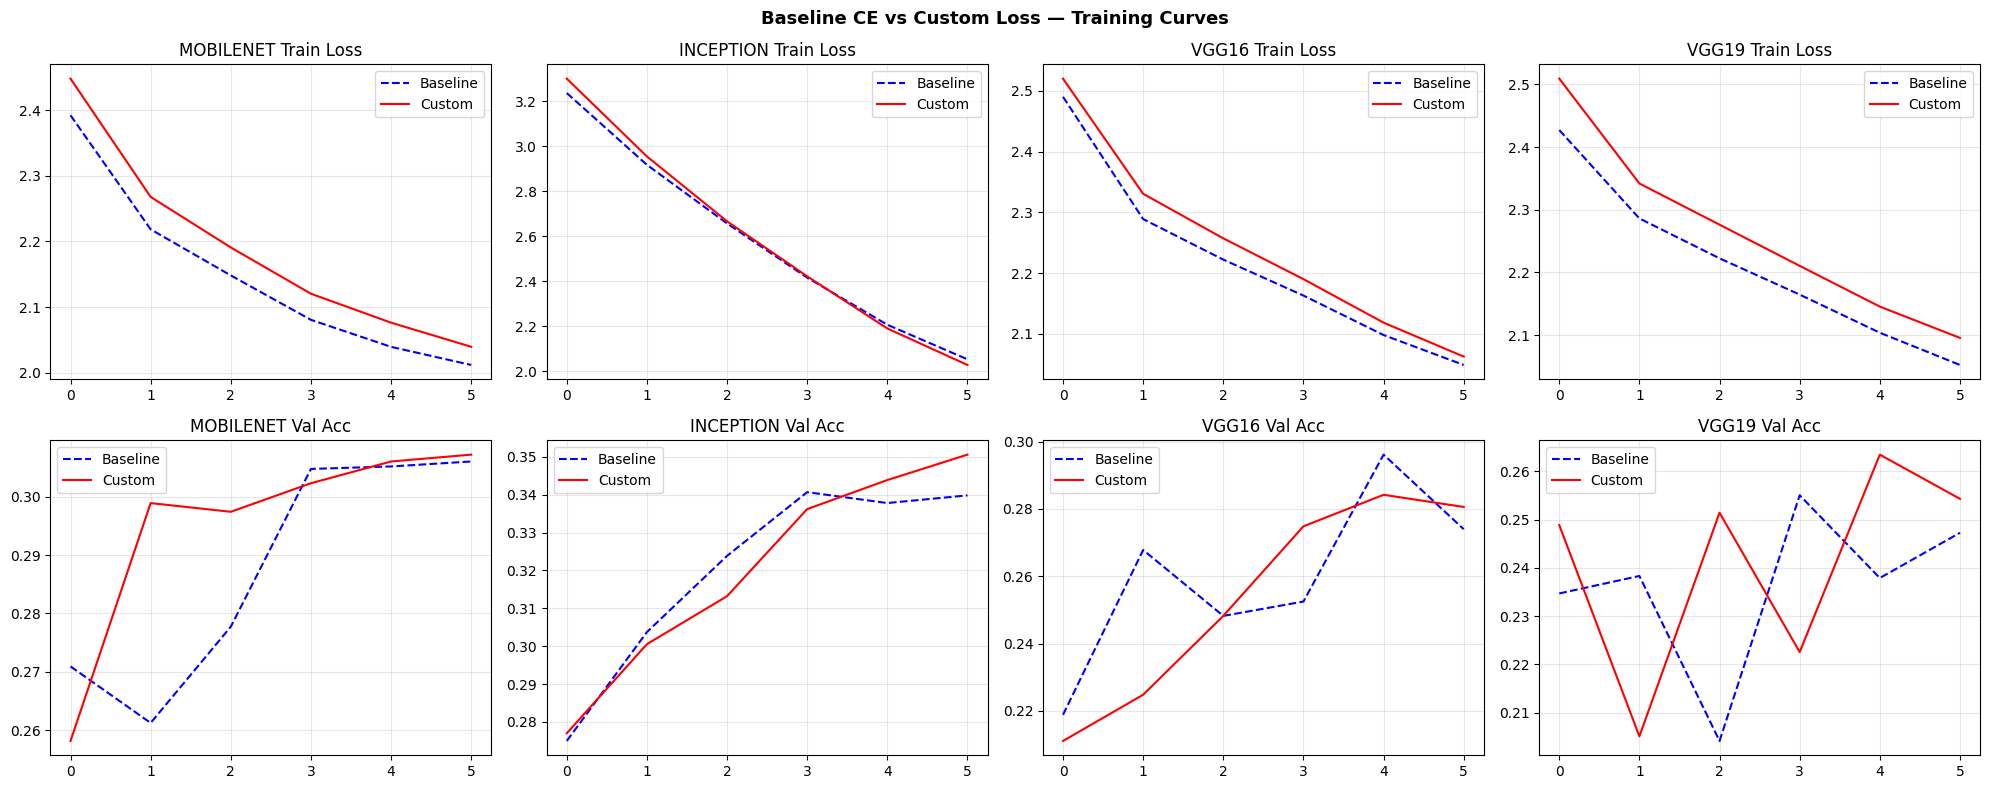

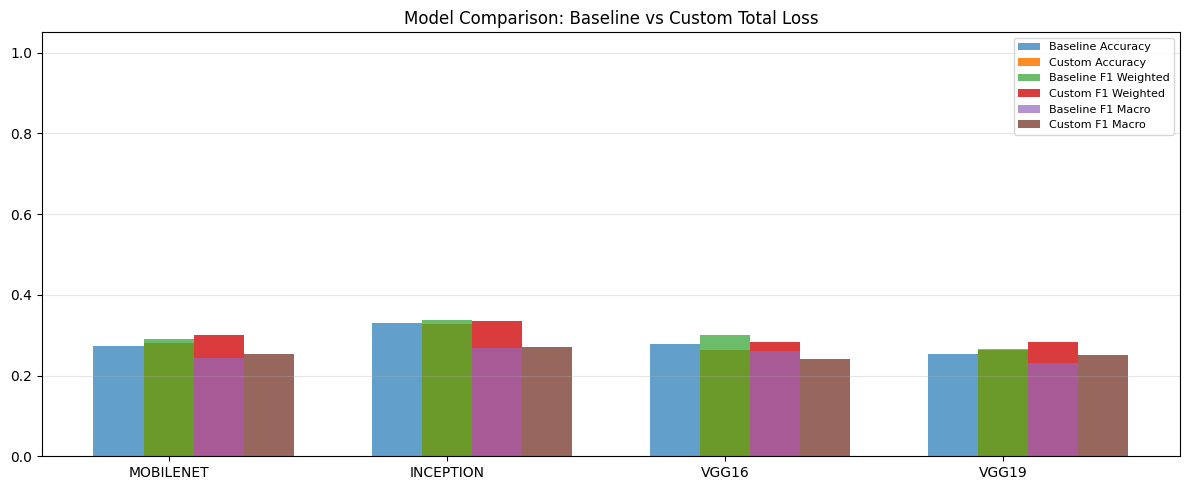

In [15]:

fig, axes = plt.subplots(2, 4, figsize=(20,8))
fig.suptitle('Baseline CE vs Custom Loss — Training Curves', fontsize=13, fontweight='bold')

for col, m in enumerate(MODELS):
    b = next(r for r in results if r['model']==m and r['loss']=='baseline')
    c = next(r for r in results if r['model']==m and r['loss']=='custom')
    axes[0][col].plot(b['hist']['tl'],'b--',label='Baseline')
    axes[0][col].plot(c['hist']['tl'],'r-', label='Custom')
    axes[0][col].set_title(f'{m.upper()} Train Loss'); axes[0][col].legend(); axes[0][col].grid(alpha=0.3)
    axes[1][col].plot(b['hist']['va'],'b--',label='Baseline')
    axes[1][col].plot(c['hist']['va'],'r-', label='Custom')
    axes[1][col].set_title(f'{m.upper()} Val Acc'); axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('learning_curves.png',dpi=120); plt.show()


fig,ax = plt.subplots(figsize=(12,5))
x = np.arange(len(MODELS)); w = 0.18
for i,(metric,lbl) in enumerate([('acc','Accuracy'),('f1w','F1 Weighted'),('f1m','F1 Macro')]):
    bv = [r[metric] for r in results if r['loss']=='baseline']
    cv = [r[metric] for r in results if r['loss']=='custom']
    ax.bar(x+(2*i-2)*w/2,    bv, w, label=f'Baseline {lbl}', alpha=0.7)
    ax.bar(x+(2*i-2)*w/2+w,  cv, w, label=f'Custom {lbl}',   alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in MODELS])
ax.set_title('Model Comparison: Baseline vs Custom Total Loss')
ax.legend(fontsize=8); ax.set_ylim(0,1.05); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('comparison.png',dpi=120); plt.show()

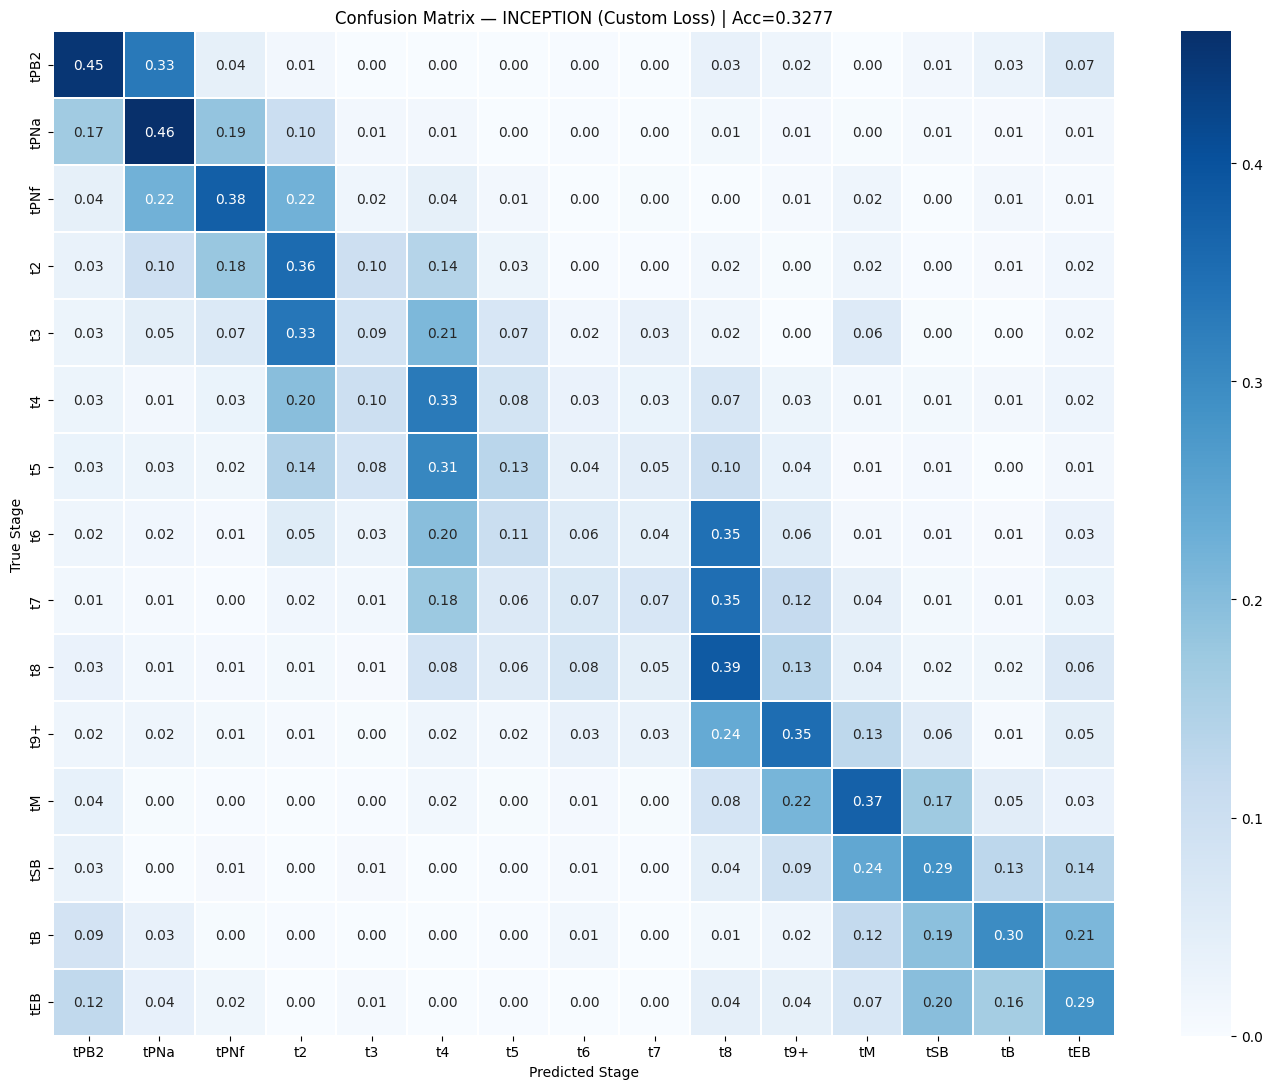

              precision    recall  f1-score   support

        tPB2       0.20      0.45      0.28       292
        tPNa       0.63      0.46      0.53      1312
        tPNf       0.14      0.38      0.21       223
          t2       0.37      0.36      0.36       857
          t3       0.07      0.09      0.08       230
          t4       0.34      0.33      0.34       832
          t5       0.14      0.13      0.13       304
          t6       0.07      0.06      0.06       294
          t7       0.16      0.07      0.10       404
          t8       0.29      0.39      0.33       874
         t9+       0.55      0.35      0.43      1498
          tM       0.27      0.37      0.31       523
         tSB       0.28      0.29      0.28       575
          tB       0.32      0.30      0.31       407
         tEB       0.29      0.29      0.29       573

    accuracy                           0.33      9198
   macro avg       0.27      0.29      0.27      9198
weighted avg       0.36   

In [16]:
# Confusion matrix for best custom-loss model
best = max((r for r in results if r['loss']=='custom'), key=lambda r: r['acc'])
cm   = confusion_matrix(best['targets'], best['preds'])
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14,11))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[PHASES[i] for i in range(NUM_CLASSES)],
            yticklabels=[PHASES[i] for i in range(NUM_CLASSES)], linewidths=0.3)
plt.title(f'Confusion Matrix — {best["model"].upper()} (Custom Loss) | Acc={best["acc"]:.4f}', fontsize=12)
plt.ylabel('True Stage'); plt.xlabel('Predicted Stage')
plt.tight_layout(); plt.savefig('confusion_matrix.png',dpi=120); plt.show()

print(classification_report(best['targets'], best['preds'],
      target_names=[PHASES[i] for i in range(NUM_CLASSES)], zero_division=0))